In [1]:
import torch
import os
from utilities import *
device = torch.device('xpu')
print(device)

xpu


c:\Users\runan\kan-robustness-scaling\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# Parameters

ranges = [-1, 1]
n_train = 1000
n_test = 1000
steps = 1200
grids = [3, 5, 10, 20, 50, 100]
k=3
lr=1
dimensions = [5, 10, 20, 50, 100, 200, 500, 1000]
seeds = [0]

In [ ]:
def train_all_seeds(data):
    static_kan = {}
    dyn_kan = {}
    mlp = {}

    for seed in seeds:
        
        static_kan_results = {}
        dyn_kan_results = {}
        mlp_results = {}
        
        for d in dimensions:
            dataset_path = os.path.join("datasets", f'seed {seed}', f'{data}_dataset_dim{d}_seed{seed}.pt')
            if os.path.exists(dataset_path):
                dataset = torch.load(dataset_path, map_location='cpu')
            else:
                raise FileNotFoundError(f"Dataset file not found: {dataset_path}")
            width = [d, 1, 1]
            kan_param = (width[0] * width[1] * (grids[0] + k + 3) + width[1]) + (width[1] * width[2] * (grids[0] + k + 3) + width[2])
            mlp_hidden_width = math.ceil((10*d+11)/(d+2)) - 1

            static_kan_results[d] = train_kan(width=width, dataset=dataset, static=True, seed=seed, steps=steps,grids=grids, lr=lr, k=k)
            dyn_kan_results[d] = train_kan(width=width, dataset=dataset, static=False, seed=seed, steps=steps, grids=grids, lr=lr, k=k)
            mlp_results[d] = train_mlp(width=[d, mlp_hidden_width, 1], dataset=dataset, seed=seed, steps=steps, lr=lr)
            mlp_param = mlp_results[d]['param_counts']
            print(f"Dimension {d}: KAN params: {kan_param}, MLP params: {mlp_param}")
        
        static_kan[seed] = static_kan_results
        dyn_kan[seed] = dyn_kan_results
        mlp[seed] = mlp_results
    
    output_dir = os.path.join("3-results-train-loss", f'seed-{seeds[0]}')
    os.makedirs(output_dir, exist_ok=True)
    torch.save(static_kan, os.path.join(output_dir, f'static_kan_{data}.pt'))
    torch.save(dyn_kan, os.path.join(output_dir, f'dyn_kan_{data}.pt'))
    torch.save(mlp, os.path.join(output_dir, f'mlp_{data}.pt'))
    return static_kan, dyn_kan, mlp


In [ ]:
static_kan_A, dyn_kan_A, mlp_A = train_all_seeds('A')

In [ ]:
static_kan_B, dyn_kan_B, mlp_B = train_all_seeds('B')

In [ ]:
static_kan_C, dyn_kan_C, mlp_C = train_all_seeds('C')

In [17]:
def merge_seed_results(results, seed):
    if isinstance(results, dict) and all(isinstance(k, int) for k in results.keys()):
        return results
    return {seed: results}


def load_3results_all_seeds(data):
    static_kan = {}
    dyn_kan = {}
    mlp = {}
    for seed in seeds:
        result_dir = os.path.join("3-results", f"seed-{seed}")
        loaded_static = torch.load(os.path.join(result_dir, f"static_kan_{data}.pt"), map_location='cpu', weights_only=False)
        loaded_dyn = torch.load(os.path.join(result_dir, f"dyn_kan_{data}.pt"), map_location='cpu', weights_only=False)
        loaded_mlp = torch.load(os.path.join(result_dir, f"mlp_{data}.pt"), map_location='cpu', weights_only=False)

        for seed_key, result in merge_seed_results(loaded_static, seed).items():
            static_kan[seed_key] = result
        for seed_key, result in merge_seed_results(loaded_dyn, seed).items():
            dyn_kan[seed_key] = result
        for seed_key, result in merge_seed_results(loaded_mlp, seed).items():
            mlp[seed_key] = result

    return static_kan, dyn_kan, mlp

static_kan_A, dyn_kan_A, mlp_A = load_3results_all_seeds('A')
static_kan_B, dyn_kan_B, mlp_B = load_3results_all_seeds('B')
static_kan_C, dyn_kan_C, mlp_C = load_3results_all_seeds('C')

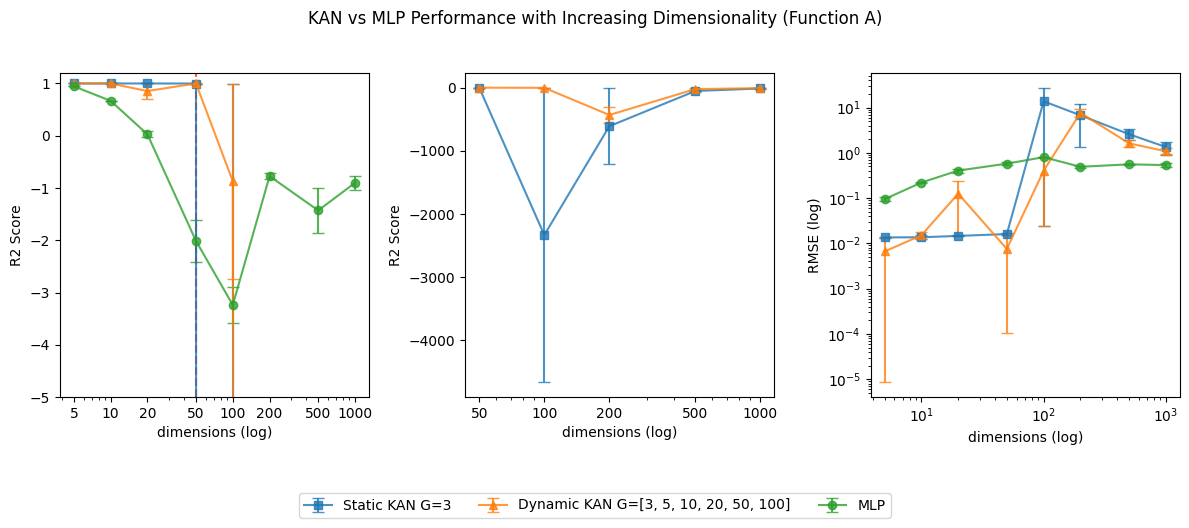

In [19]:
plot_r2s_rmses(static_kan_A, dyn_kan_A, mlp_A, dimensions, seeds, 'A', plot_mlp=False)

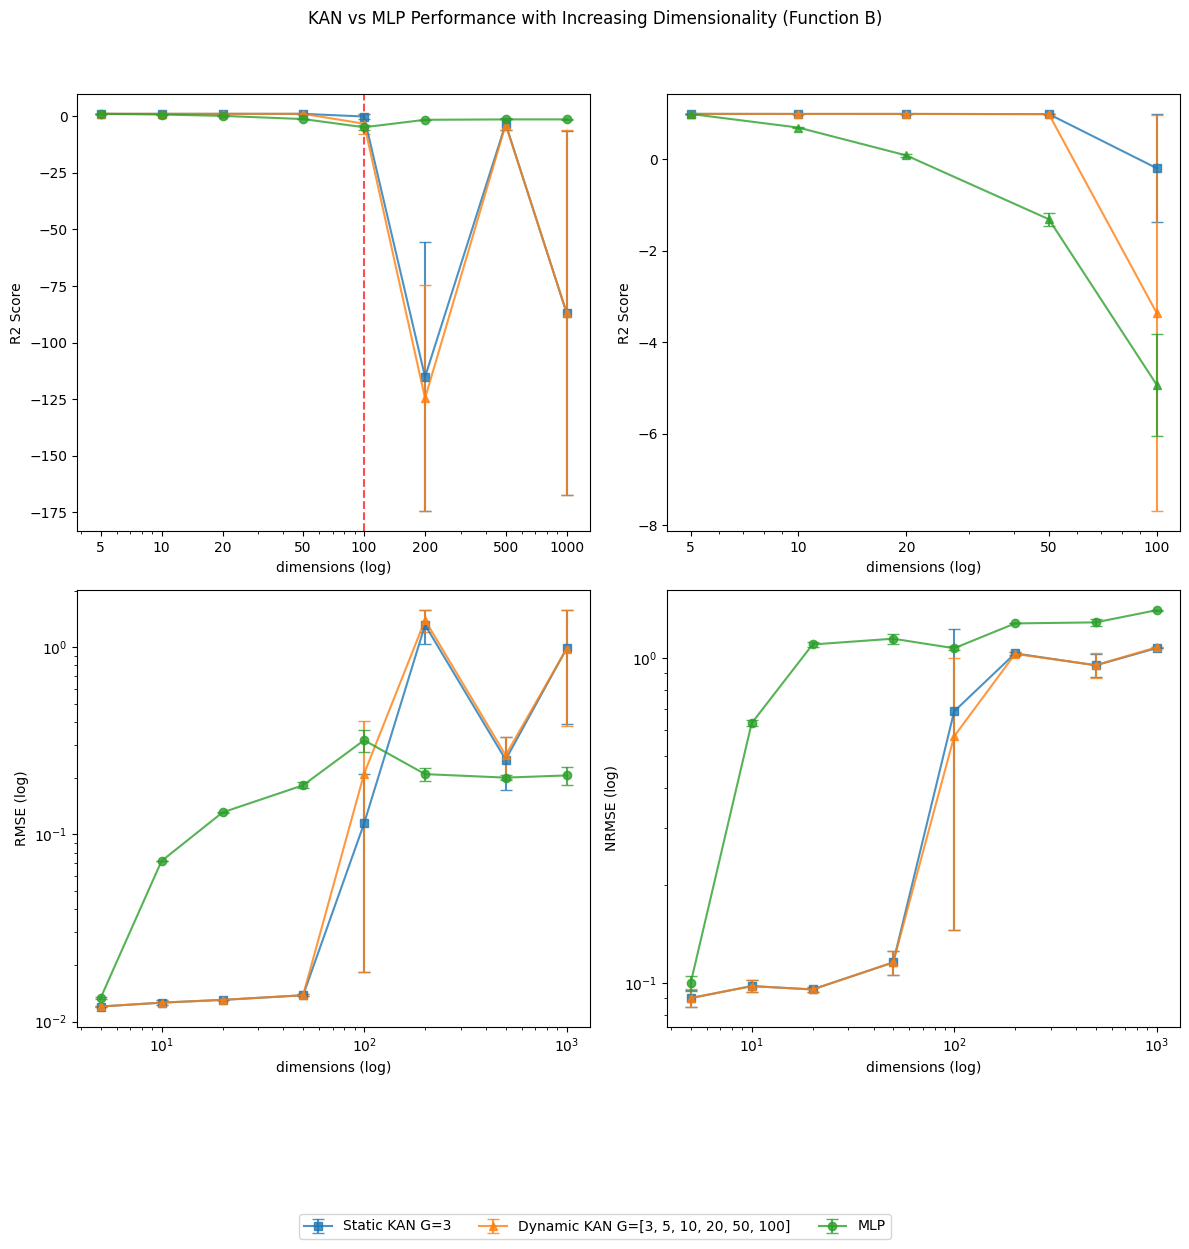

In [ ]:
plot_r2s_rmses(static_kan_B, dyn_kan_B, mlp_B, dimensions, seeds, 'B', plot_mlp=True, cutoff=3)

In [ ]:
plot_r2s_rmses(static_kan_C, dyn_kan_C, mlp_C, dimensions, seeds, 'C', plot_mlp=True)